# Smart Garbage Classification System

**Dataset Link:** https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification/data  

- The dataset used is the **Garbage Classification Dataset** from Kaggle (the TrashNet dataset), containing **2527 labeled images** across **6 waste categories** — Cardboard, Glass, Metal, Paper, Plastic, and Trash.
- Images are in .jpg format, captured under varying real-world conditions including different lighting, backgrounds, and orientations.
- The dataset is split into **70% training, 15% validation and 15% test**, stratified by class. The validation set is used for early stopping and model selection; the test set is used **only once**, for the final reported results.

---
## Problem Statement

### Real-World Problem
- Improper waste disposal is one of the leading contributors to environmental degradation.
- Manual sorting of garbage at recycling facilities is slow, inconsistent, and expensive.
- An automated classification system that can identify the type of waste from an image enables smart bins, automated sorting conveyors, and recycling pipelines — reducing human error and operational cost.

### Learning Task Definition

**Input Representation:**
Each input is an RGB image of size 224 x 224 x 3, representing a real-world waste item
captured under varying lighting conditions, backgrounds, and orientations. Pixel values
are normalized to the range [0, 1] by dividing by 255.

**Expected Output:**
The model outputs a probability distribution over 6 waste categories:
Cardboard, Glass, Metal, Paper, Plastic, and Trash.
The predicted class is the category with the highest probability.

**Type of Learning Task:**
This is a supervised multi-class image classification task. The model learns a mapping
from input image space to one of 6 discrete class labels using labeled training data.

**Real-World Relevance:**
It can be deployed in smart waste bins that automatically sort garbage at the point
of disposal, reducing contamination in recycling streams and minimizing the volume
of recyclable material sent to landfills.

---
## Setup & Install Dependencies

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # hide TensorFlow's C++ startup logs
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
keras.utils.set_random_seed(SEED)   # seeds Python, NumPy and TensorFlow
os.makedirs('results', exist_ok=True)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version:      {keras.__version__}')
print(f'GPU Available:      {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.19.0
Keras version:      3.15.1
GPU Available:      []


---
## Download Dataset from Kaggle

On Colab, add `KAGGLE_USERNAME` and `KAGGLE_KEY` under **Secrets** (key icon in the left sidebar) — never paste them into the notebook.
To run locally instead, set the `GARBAGE_DATA_DIR` environment variable to a folder containing the six class folders.

In [2]:
DATA_DIR = os.environ.get('GARBAGE_DATA_DIR')

if DATA_DIR is None:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    !pip install kaggle -q
    !kaggle datasets download -d asdasdasasdas/garbage-classification
    !unzip -q -o garbage-classification.zip -d garbage_data
    DATA_DIR = 'garbage_data'

# Auto-detect the folder that contains the class sub-folders
base_dir = None
for root, dirs, _ in os.walk(DATA_DIR):
    if len(dirs) >= 5:
        base_dir = root
        break
print(f'Dataset directory: {base_dir}')

Dataset directory: garbage_data/dataset-resized


---
##  Data Exploration

In [3]:
class_names = sorted(d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)))
IMG_EXTS = ('.jpg', '.jpeg', '.png')

class_counts = {}
for cls in class_names:
    files = [f for f in os.listdir(os.path.join(base_dir, cls)) if f.lower().endswith(IMG_EXTS)]
    class_counts[cls] = len(files)
    print(f'  {cls:<12}: {len(files)} images')
print(f'\nTotal images: {sum(class_counts.values())}')

  cardboard   : 403 images
  glass       : 501 images
  metal       : 410 images
  paper       : 594 images
  plastic     : 482 images
  trash       : 137 images

Total images: 2527


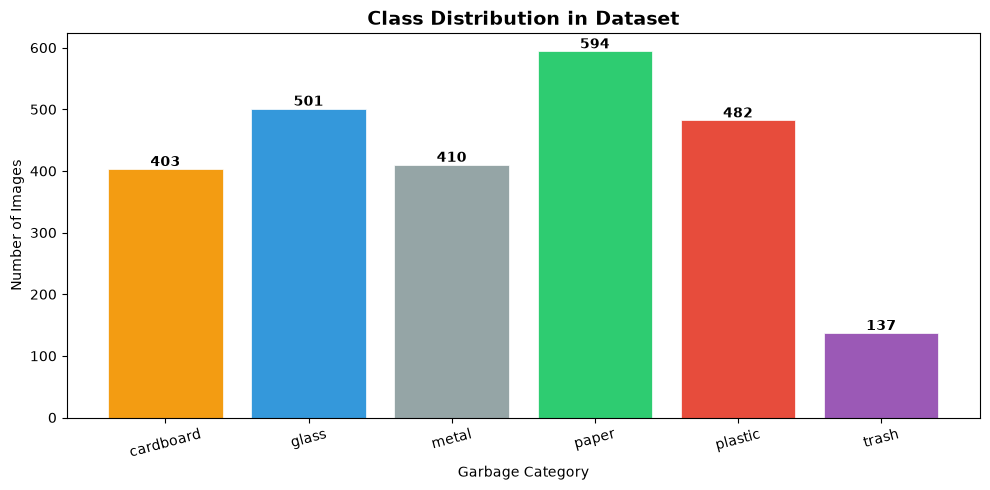

Saved: results/class_distribution.png


In [4]:
# Class distribution bar chart
colors = ['#f39c12','#3498db','#95a5a6','#2ecc71','#e74c3c','#9b59b6']
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=0.5)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Garbage Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/class_distribution.png')

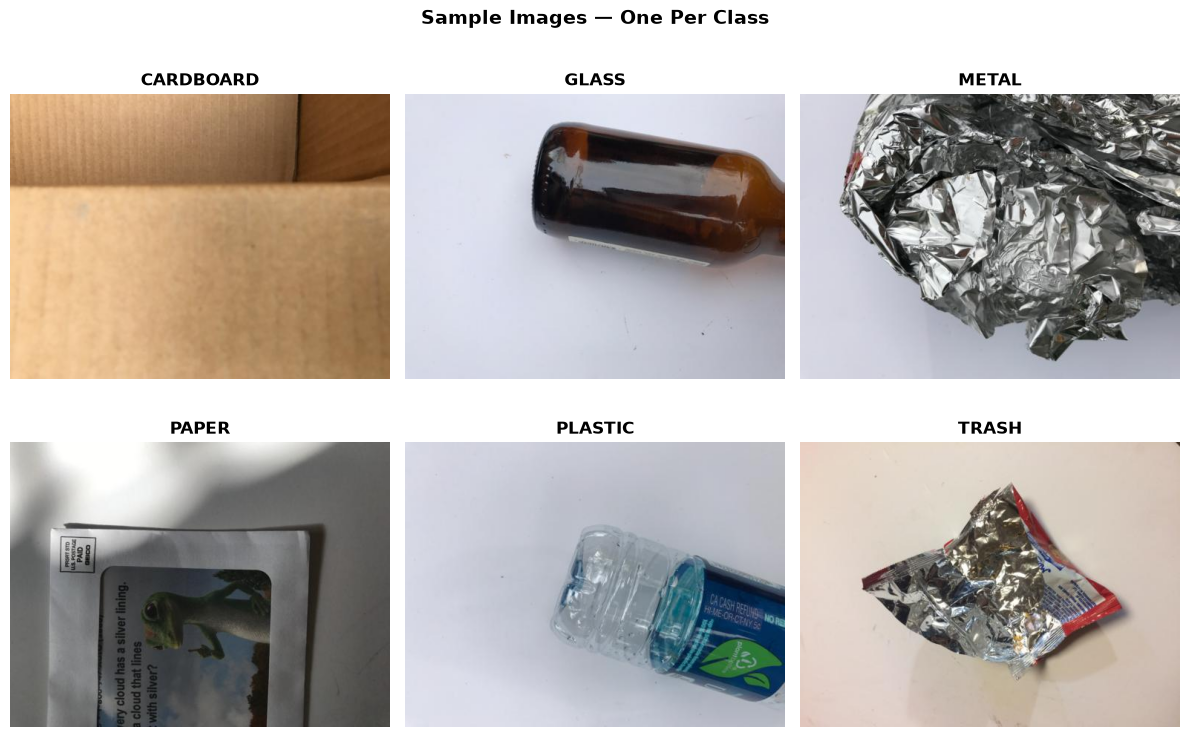

In [5]:
# Sample images from each class
classes = class_names
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for idx, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.upper(), fontsize=12, fontweight='bold')
    axes[idx].axis('off')
plt.suptitle('Sample Images — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Train / Validation / Test Split (70 / 15 / 15)

The original version of this notebook used an 80/20 train/validation split and reported the validation accuracy as the final result. That number is optimistic: the validation set was also used to decide when to stop training and which weights to keep, so it indirectly influenced the model.

Here the data is split three ways, **stratified by class** so every split has the same class proportions (important for the small *trash* class):

| Split | Share | Used for |
|---|---|---|
| Train | 70% | Fitting the weights (with augmentation) |
| Validation | 15% | Early stopping, learning-rate schedule, choosing between models |
| Test | 15% | Final reported results — evaluated once, at the end |

In [6]:
paths, labels = [], []
for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(base_dir, cls)
    for f in sorted(os.listdir(cls_dir)):
        if f.lower().endswith(IMG_EXTS):
            paths.append(os.path.join(cls_dir, f))
            labels.append(idx)
paths, labels = np.array(paths), np.array(labels)

# 70% train, then split the remaining 30% in half: 15% validation, 15% test
train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

split_table = pd.DataFrame({
    'train': np.bincount(train_y, minlength=len(class_names)),
    'val':   np.bincount(val_y,   minlength=len(class_names)),
    'test':  np.bincount(test_y,  minlength=len(class_names)),
}, index=class_names)
split_table.loc['TOTAL'] = split_table.sum()
print(split_table)

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print('\nSaved: class_names.json')

           train  val  test
cardboard    282   61    60
glass        350   75    76
metal        287   61    62
paper        416   89    89
plastic      337   72    73
trash         96   21    20
TOTAL       1768  379   380

Saved: class_names.json


---
## Data Preprocessing & Augmentation

- Every image is resized to **224 × 224** and scaled to **[0, 1]** by dividing by 255 — the same preprocessing the Streamlit app uses.
- **Augmentation is applied to training images only**: random horizontal flips, rotation (±20°), shifts (±20%) and zoom (±20%). This is a form of regularisation: it shows the model new variations of each image every epoch.
- Validation and test images are only resized and scaled, so they reflect real inference conditions.

In [7]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = len(class_names)
AUTOTUNE    = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32) / 255.0, tf.one_hot(label, NUM_CLASSES)

augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(20 / 360, fill_mode='nearest'),
    layers.RandomTranslation(0.2, 0.2, fill_mode='nearest'),
    layers.RandomZoom(0.2, fill_mode='nearest'),
], name='augmentation')

def make_dataset(p, y, training):
    ds = tf.data.Dataset.from_tensor_slices((p, y)).map(load_image, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(p), seed=SEED)
        ds = ds.batch(BATCH_SIZE).map(lambda x, t: (augment(x, training=True), t), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_p, train_y, training=True)
val_ds   = make_dataset(val_p,   val_y,   training=False)
test_ds  = make_dataset(test_p,  test_y,  training=False)
print(f'Train: {len(train_p)}  |  Validation: {len(val_p)}  |  Test: {len(test_p)}')

Train: 1768  |  Validation: 379  |  Test: 380


---
## Model 1 — Custom CNN (from scratch)

**Hypothesis:** A custom 4-block CNN with L2 regularization and Dropout should be able to classify garbage images.

**Architecture:**
- 4 × [Conv2D → BatchNorm → MaxPool] blocks
- GlobalAveragePooling
- Dense(512) + Dropout(0.5)
- Dense(256) + Dropout(0.3)
- Dense(6, Softmax)

**Regularization applied:** L2 on all Conv layers, Dropout on Dense layers, EarlyStopping, Data Augmentation

---
## Mathematical Modeling

### Why a Custom CNN?

A custom CNN was built from scratch to demonstrate understanding of how each component
of a convolutional network works — convolutional layers, pooling, regularization, and
the classification head. The architecture uses 4 convolutional blocks that progressively
extract deeper features, starting from edges and textures in the early layers to
object-level patterns in the deeper layers.

This custom CNN is the **baseline**. Model 2 below compares it against transfer
learning with MobileNetV2, which reuses features learned from 1.2 million ImageNet images.

---

### Architecture Formulation

**Convolution:**
A 3x3 filter slides over the input image and computes a dot product at each position
to detect local patterns such as edges, textures, and shapes.

    Output[i,j] = sum( Input[i+m, j+n] * Filter[m,n] ) + bias

**ReLU Activation:**
Applied after every Conv layer. Removes negative values, introducing non-linearity
so the network can learn complex patterns.

    f(x) = max(0, x)

**Batch Normalization:**
Normalizes the output of each Conv layer to have zero mean and unit variance.
Stabilizes and speeds up training.

**MaxPooling:**
Takes the maximum value from each 2x2 region, halving the spatial dimensions after
each block. Reduces computation and keeps only the strongest features.

    Output[i,j] = max value in 2x2 window

**GlobalAveragePooling:**
Takes the average of each feature map instead of flattening. Reduces parameters
significantly and improves generalization.

**Softmax Output:**
Converts final layer scores into probabilities across 6 classes. The class with
the highest probability is the prediction.

    y_hat_i = exp(z_i) / sum( exp(z_j) )

---

### Loss Function

**Categorical Cross-Entropy:**

    L = - sum( y_i * log(y_hat_i) )

Measures the difference between the true label and the predicted probability.
Penalizes confident wrong predictions heavily.

---

### Training Strategy

**Optimizer: Adam** with an initial learning rate of 0.001. Adam adapts the learning
rate for each parameter individually, making it faster and more stable than standard SGD.

**Backpropagation:** Gradients are computed using the chain rule and weights are
updated after each batch to minimize the loss.

**ReduceLROnPlateau:** Halves the learning rate if validation loss does not improve
for 3 consecutive epochs, allowing finer weight updates in later training.

---

### Evaluation Metrics

- **Accuracy:** Overall percentage of correct predictions
- **Precision:** Of all predictions for class C, how many were actually class C
- **Recall:** Of all actual class C samples, how many were correctly predicted
- **F1-Score:** Harmonic mean of precision and recall — used as the main per-class
  metric since the dataset has class imbalance (Trash has only 137 images in total)
- **Confusion Matrix:** Shows which classes are being confused with each other

In [8]:
# Build Custom CNN
def build_custom_cnn(num_classes=6):
    model = models.Sequential([
        # Input layer
        keras.Input(shape=(224, 224, 3)),

        # Block 1 — low-level features (edges, gradients)
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool1'),

        # Block 2 — mid-level features (textures, patterns)
        layers.Conv2D(64, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool2'),

        # Block 3 — high-level features (object parts)
        layers.Conv2D(128, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool3'),

        # Block 4 — deeper abstract features
        layers.Conv2D(256, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv4'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool4'),

        # Classification head
        layers.GlobalAveragePooling2D(name='gap'),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),    # Drop 50% neurons — prevents co-adaptation
        layers.Dense(256, activation='relu', name='dense2'),
        layers.Dropout(0.3, name='dropout2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()
print(f'Total parameters: {cnn_model.count_params():,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,790 (2.50 MB)

 Trainable params: 653,830 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

Total parameters: 654,790


---
## Model Design, Implementation and Regularization

### Why Regularization Was Applied from the Start

The dataset has only ~1,770 training images across 6 classes — under 300 images per
class on average. The model has 654,790 parameters. When a model has high capacity relative to
limited data, it tends to memorize training images instead of learning general patterns.
To prevent this from the beginning, three regularization techniques were built directly
into the architecture.

**L2 Regularization — on all Conv2D layers:**
Adds a penalty on large weights to the loss function.

    Total Loss = Cross-Entropy Loss + 0.001 * sum(weights^2)

This discourages the model from relying heavily on any specific pixel pattern,
producing smoother and more generalizable feature representations.

**Dropout — on Dense layers (p=0.5 and p=0.3):**
Randomly deactivates neurons during training. This prevents neurons from depending
on each other to memorize specific examples, forcing each neuron to independently
learn useful features. Dropout is disabled during prediction.

**Data Augmentation — on training images only:**
Random rotation, flipping, zoom, and shifts are applied to training images. This
artificially increases dataset variety and teaches the model to recognize waste items
regardless of orientation or position. Augmentation is a form of regularization
as covered in Unit 2 of the course.



In [9]:
# Loss: Categorical Cross-Entropy  →  L = -Σ y_i * log(ŷ_i)
# Optimizer: Adam — adaptive learning rates per parameter
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

def training_callbacks(patience=5, start_from_epoch=0):
    return [
        EarlyStopping(monitor='val_loss', patience=patience, start_from_epoch=start_from_epoch,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]

# A CNN trained from scratch has a very noisy validation loss in its first epochs,
# so early stopping only starts counting after epoch 10, with a patience of 7
EPOCHS_CNN = 25
history_cnn = cnn_model.fit(
    train_ds,
    epochs=EPOCHS_CNN,
    validation_data=val_ds,
    callbacks=training_callbacks(patience=7, start_from_epoch=10),
    verbose=2
)

Epoch 1/25


56/56 - 67s - 1s/step - accuracy: 0.4440 - loss: 1.7509 - val_accuracy: 0.2348 - val_loss: 2.1292 - learning_rate: 0.0010


Epoch 2/25


56/56 - 56s - 992ms/step - accuracy: 0.4915 - loss: 1.5997 - val_accuracy: 0.2269 - val_loss: 2.1353 - learning_rate: 0.0010


Epoch 3/25


...

56/56 - 71s - 1s/step - accuracy: 0.7670 - loss: 0.8177 - val_accuracy: 0.7942 - val_loss: 0.8379 - learning_rate: 1.2500e-04


Epoch 25/25



Epoch 25: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


56/56 - 59s - 1s/step - accuracy: 0.7743 - loss: 0.7859 - val_accuracy: 0.7731 - val_loss: 0.8734 - learning_rate: 1.2500e-04


Restoring model weights from the end of the best epoch: 22.


---
## Model 2 — Transfer Learning with MobileNetV2

**Why transfer learning?** With under 2,000 training images, a network trained from scratch has to learn everything — edges, textures, shapes — from very little data. MobileNetV2 has already learned those general visual features from **1.2 million ImageNet images**. We reuse that feature extractor and only teach it to recognise our 6 waste classes.

**Architecture:**
- Input in [0, 1] → rescaled to [-1, 1] inside the model (the range MobileNetV2 was trained on), so the Streamlit app needs no extra preprocessing
- MobileNetV2 base (ImageNet weights, no top classifier)
- GlobalAveragePooling → Dropout(0.3) → Dense(6, Softmax)

**Two-phase training:**
1. **Feature extraction** — the MobileNetV2 base is frozen; only the new classification head is trained (learning rate 1e-3).
2. **Fine-tuning** — the top 40 layers of the base are unfrozen and trained together with the head at a much lower learning rate (1e-5), so the pretrained features adapt to waste images without being destroyed.

All BatchNorm layers in the base stay **frozen** during fine-tuning, so they keep using their ImageNet statistics. An unfrozen BatchNorm layer would switch to per-batch statistics while training, which disrupts the pretrained features on a small dataset.

In [10]:
def build_mobilenetv2(num_classes=6):
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base.trainable = False

    inputs  = keras.Input(shape=(224, 224, 3))
    x       = layers.Rescaling(2.0, offset=-1.0, name='to_minus1_1')(inputs)   # [0,1] → [-1,1]
    x       = base(x, training=False)                                          # keep BatchNorm in inference mode
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs, outputs, name='mobilenetv2_garbage'), base

mnv2_model, mnv2_base = build_mobilenetv2(NUM_CLASSES)
mnv2_model.summary()
print(f'Total parameters:     {mnv2_model.count_params():,}')
print(f'Trainable (phase 1):  {sum(np.prod(w.shape) for w in mnv2_model.trainable_weights):,}')

Model: "mobilenetv2_garbage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_minus1_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters:     2,265,670
Trainable (phase 1):  7,686


In [11]:
# Phase 1 — train the classification head only
EPOCHS_HEAD = 15
mnv2_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
history_head = mnv2_model.fit(train_ds, epochs=EPOCHS_HEAD, validation_data=val_ds,
                              callbacks=training_callbacks(), verbose=2)

Epoch 1/15


56/56 - 28s - 505ms/step - accuracy: 0.4887 - loss: 1.3645 - val_accuracy: 0.7098 - val_loss: 0.7968 - learning_rate: 0.0010


Epoch 2/15


56/56 - 22s - 389ms/step - accuracy: 0.6895 - loss: 0.8357 - val_accuracy: 0.7573 - val_loss: 0.6496 - learning_rate: 0.0010


Epoch 3/15


...

Epoch 14/15


56/56 - 22s - 397ms/step - accuracy: 0.8371 - loss: 0.4350 - val_accuracy: 0.8232 - val_loss: 0.5381 - learning_rate: 0.0010


Epoch 15/15


56/56 - 21s - 371ms/step - accuracy: 0.8354 - loss: 0.4356 - val_accuracy: 0.8206 - val_loss: 0.5138 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 15.


In [12]:
# Phase 2 — fine-tune the top 40 layers of the base at a low learning rate
FINE_TUNE_LAYERS = 40
EPOCHS_FINE      = 10

mnv2_base.trainable = True
for layer in mnv2_base.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
# Keep every BatchNorm layer frozen: an unfrozen BatchNorm switches to batch statistics
# during training, which disrupts the pretrained features on a small dataset
for layer in mnv2_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

mnv2_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                   loss='categorical_crossentropy', metrics=['accuracy'])
print(f'Trainable (phase 2): {sum(np.prod(w.shape) for w in mnv2_model.trainable_weights):,}')

history_fine = mnv2_model.fit(train_ds, epochs=EPOCHS_FINE, validation_data=val_ds,
                              callbacks=training_callbacks(), verbose=2)

# Combine both phases into one history for plotting
history_mnv2 = {k: history_head.history[k] + history_fine.history[k]
                for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
fine_tune_start = len(history_head.history['accuracy'])

Trainable (phase 2): 1,671,046
Epoch 1/10


56/56 - 31s - 559ms/step - accuracy: 0.8512 - loss: 0.3952 - val_accuracy: 0.8127 - val_loss: 0.5086 - learning_rate: 1.0000e-05


Epoch 2/10


56/56 - 27s - 482ms/step - accuracy: 0.8773 - loss: 0.3461 - val_accuracy: 0.8285 - val_loss: 0.4993 - learning_rate: 1.0000e-05


Epoch 3/10


...

56/56 - 25s - 438ms/step - accuracy: 0.9084 - loss: 0.2653 - val_accuracy: 0.8417 - val_loss: 0.4694 - learning_rate: 1.0000e-05


Epoch 10/10



Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.


56/56 - 26s - 468ms/step - accuracy: 0.9044 - loss: 0.2737 - val_accuracy: 0.8391 - val_loss: 0.4650 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 7.


---
## Training Curves

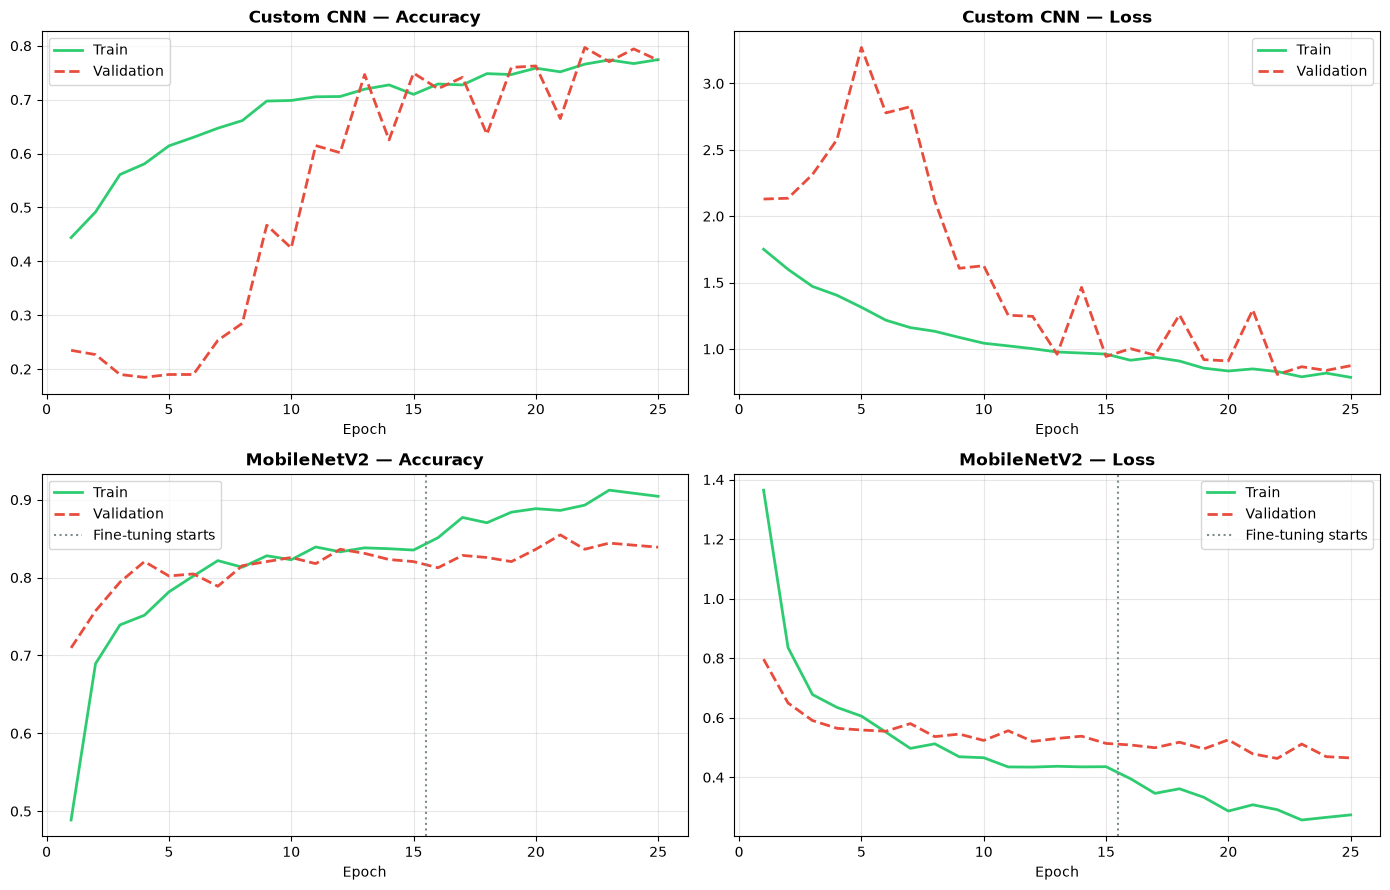

In [13]:
hist_cnn = {k: history_cnn.history[k] for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (name, h) in enumerate([('Custom CNN', hist_cnn), ('MobileNetV2', history_mnv2)]):
    ep = range(1, len(h['accuracy']) + 1)
    for col, metric in enumerate(['accuracy', 'loss']):
        ax = axes[row, col]
        ax.plot(ep, h[metric], label='Train', color='#2ecc71', linewidth=2)
        ax.plot(ep, h['val_' + metric], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
        if name == 'MobileNetV2':
            ax.axvline(fine_tune_start + 0.5, color='#7f8c8d', linestyle=':', label='Fine-tuning starts')
        ax.set_title(f'{name} — {metric.capitalize()}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Final Evaluation on the Test Set

Both models are evaluated **once** on the held-out test set, which played no part in training, early stopping or model selection.

In [14]:
def evaluate(model, name):
    # Validation accuracy of the final weights (EarlyStopping restored the best-val_loss epoch)
    val_acc = model.evaluate(val_ds, verbose=0)[1]
    print(f'{name} — Validation Accuracy (final weights): {val_acc*100:.2f}%')
    probs = model.predict(test_ds, verbose=0)
    pred  = probs.argmax(axis=1)
    acc   = accuracy_score(test_y, pred)
    print('=' * 60)
    print(f'{name} — Test Accuracy: {acc*100:.2f}%')
    print('=' * 60)
    print(classification_report(test_y, pred, target_names=class_names, digits=3, zero_division=0))
    return pred, acc, val_acc, classification_report(test_y, pred, target_names=class_names,
                                                     output_dict=True, zero_division=0)

cnn_pred,  cnn_test_acc,  cnn_val_acc,  cnn_report  = evaluate(cnn_model,  'Custom CNN')
mnv2_pred, mnv2_test_acc, mnv2_val_acc, mnv2_report = evaluate(mnv2_model, 'MobileNetV2')

Custom CNN — Validation Accuracy (final weights): 79.68%


Custom CNN — Test Accuracy: 72.63%
              precision    recall  f1-score   support

   cardboard      0.831     0.900     0.864        60
       glass      0.804     0.592     0.682        76
       metal      0.630     0.548     0.586        62
       paper      0.664     0.933     0.776        89
     plastic      0.766     0.671     0.715        73
       trash      0.688     0.550     0.611        20

    accuracy                          0.726       380
   macro avg      0.730     0.699     0.706       380
weighted avg      0.733     0.726     0.720       380



MobileNetV2 — Validation Accuracy (final weights): 83.64%


MobileNetV2 — Test Accuracy: 85.00%
              precision    recall  f1-score   support

   cardboard      0.942     0.817     0.875        60
       glass      0.867     0.855     0.861        76
       metal      0.757     0.903     0.824        62
       paper      0.847     0.933     0.888        89
     plastic      0.870     0.822     0.845        73
       trash      0.833     0.500     0.625        20

    accuracy                          0.850       380
   macro avg      0.853     0.805     0.820       380
weighted avg      0.855     0.850     0.848       380



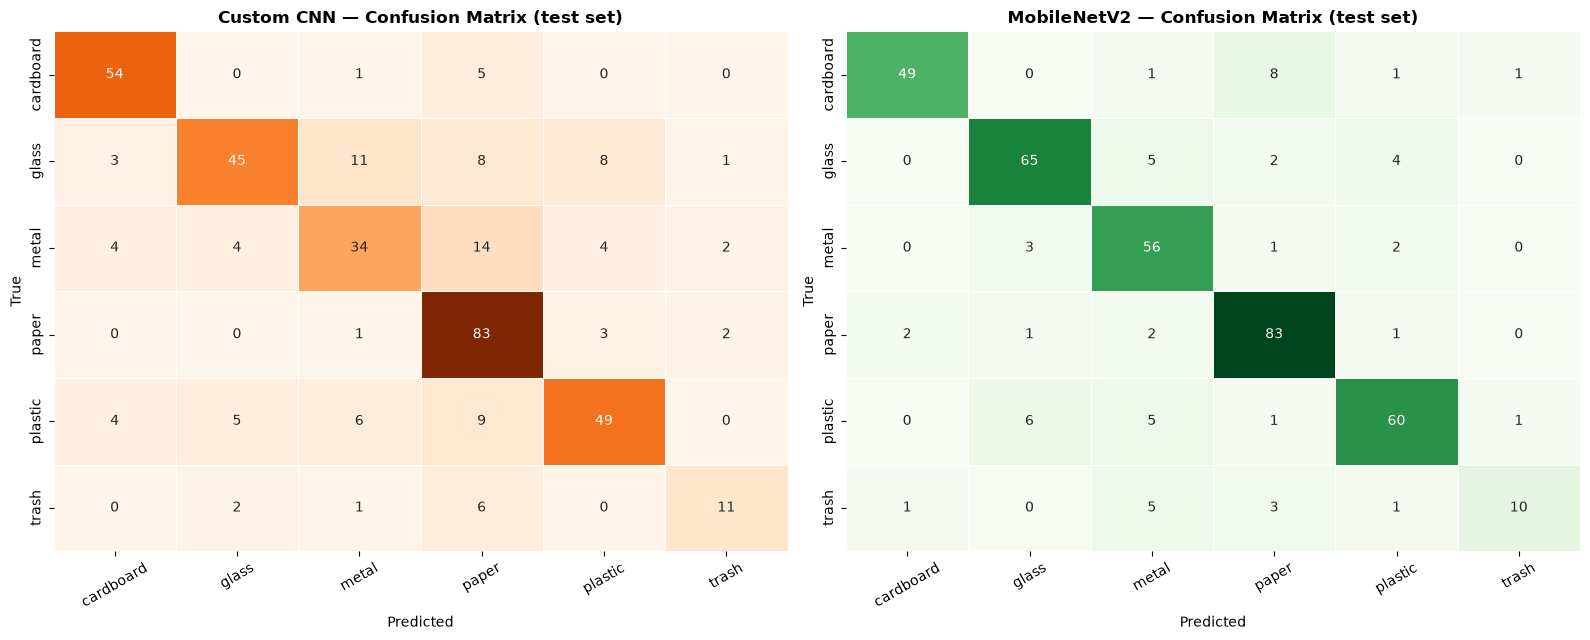

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, name, pred, cmap in [(axes[0], 'Custom CNN', cnn_pred, 'Oranges'),
                              (axes[1], 'MobileNetV2', mnv2_pred, 'Greens')]:
    cm = confusion_matrix(test_y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names,
                yticklabels=class_names, linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'{name} — Confusion Matrix (test set)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
comparison = pd.DataFrame({
    'Parameters':          [cnn_model.count_params(), mnv2_model.count_params()],
    'Epochs trained':      [len(hist_cnn['accuracy']), len(history_mnv2['accuracy'])],
    'Val. accuracy':       [cnn_val_acc, mnv2_val_acc],
    'Test accuracy':       [cnn_test_acc, mnv2_test_acc],
    'Test macro F1':       [cnn_report['macro avg']['f1-score'], mnv2_report['macro avg']['f1-score']],
}, index=['Custom CNN', 'MobileNetV2'])

per_class_f1 = pd.DataFrame({
    'Custom CNN':  [cnn_report[c]['f1-score'] for c in class_names],
    'MobileNetV2': [mnv2_report[c]['f1-score'] for c in class_names],
    'Test images': [int(cnn_report[c]['support']) for c in class_names],
}, index=class_names)

pd.options.display.float_format = '{:.3f}'.format
print(comparison, '\n')
print('Per-class F1 on the test set:')
print(per_class_f1)

             Parameters  Epochs trained  Val. accuracy  Test accuracy  \
Custom CNN       654790              25          0.797          0.726   
MobileNetV2     2265670              25          0.836          0.850   

             Test macro F1  
Custom CNN           0.706  
MobileNetV2          0.820   

Per-class F1 on the test set:
           Custom CNN  MobileNetV2  Test images
cardboard       0.864        0.875           60
glass           0.682        0.861           76
metal           0.586        0.824           62
paper           0.776        0.888           89
plastic         0.715        0.845           73
trash           0.611        0.625           20


---
## Results & Conclusions

**Test-set results** (380 images the models never saw during training or model selection):

| Model | Parameters | Val. accuracy | **Test accuracy** | Test macro F1 |
|---|---|---|---|---|
| Custom CNN (from scratch) | 654,790 | 79.7% | **72.6%** | 0.706 |
| MobileNetV2 (transfer learning) | 2,265,670 | 83.6% | **85.0%** | 0.820 |

**Per-class F1 (test set):**

| Class | Custom CNN | MobileNetV2 | Test images |
|---|---|---|---|
| Cardboard | 0.864 | 0.875 | 60 |
| Glass | 0.682 | 0.861 | 76 |
| Metal | 0.586 | 0.824 | 62 |
| Paper | 0.776 | 0.888 | 89 |
| Plastic | 0.715 | 0.845 | 73 |
| Trash | 0.611 | 0.625 | 20 |

**What the results show:**

- **Transfer learning adds 12.4 points of test accuracy** (72.6% → 85.0%). The biggest gains are on glass, metal and plastic — classes that differ in subtle surface properties (transparency, reflections) that pretrained ImageNet features capture far better than a network trained on ~1,800 images.
- **Fine-tuning helped:** unfreezing the top 40 layers (with BatchNorm frozen) lowered the best validation loss from 0.514 to 0.463.
- **The validation/test gap matters.** The custom CNN scored 79.7% on validation but 72.6% on test: its noisy validation curve means the epoch picked by early stopping partly reflects luck on the validation set. This is exactly why the final numbers come from a separate test set.
- **Trash remains the weakest class** for both models (F1 ≈ 0.6). It has only 137 images in total (20 in the test set), and MobileNetV2 most often mistakes it for metal or paper. The other notable confusion is cardboard predicted as paper.

**Limitations and next steps:**

- The test set is small (380 images; only 20 trash), so each trash error moves its F1 noticeably. K-fold cross-validation would give a more stable estimate.
- Class weighting or collecting more trash images would target the weakest class directly.
- The custom CNN was still improving at epoch 25; a longer schedule may narrow — but is unlikely to close — the gap to transfer learning.


---
## Sample Predictions (demo)

A visual check of the selected model on a few **test-set** images. This is a demonstration only — the metrics above are the actual results.

Selected model (by validation accuracy): MobileNetV2


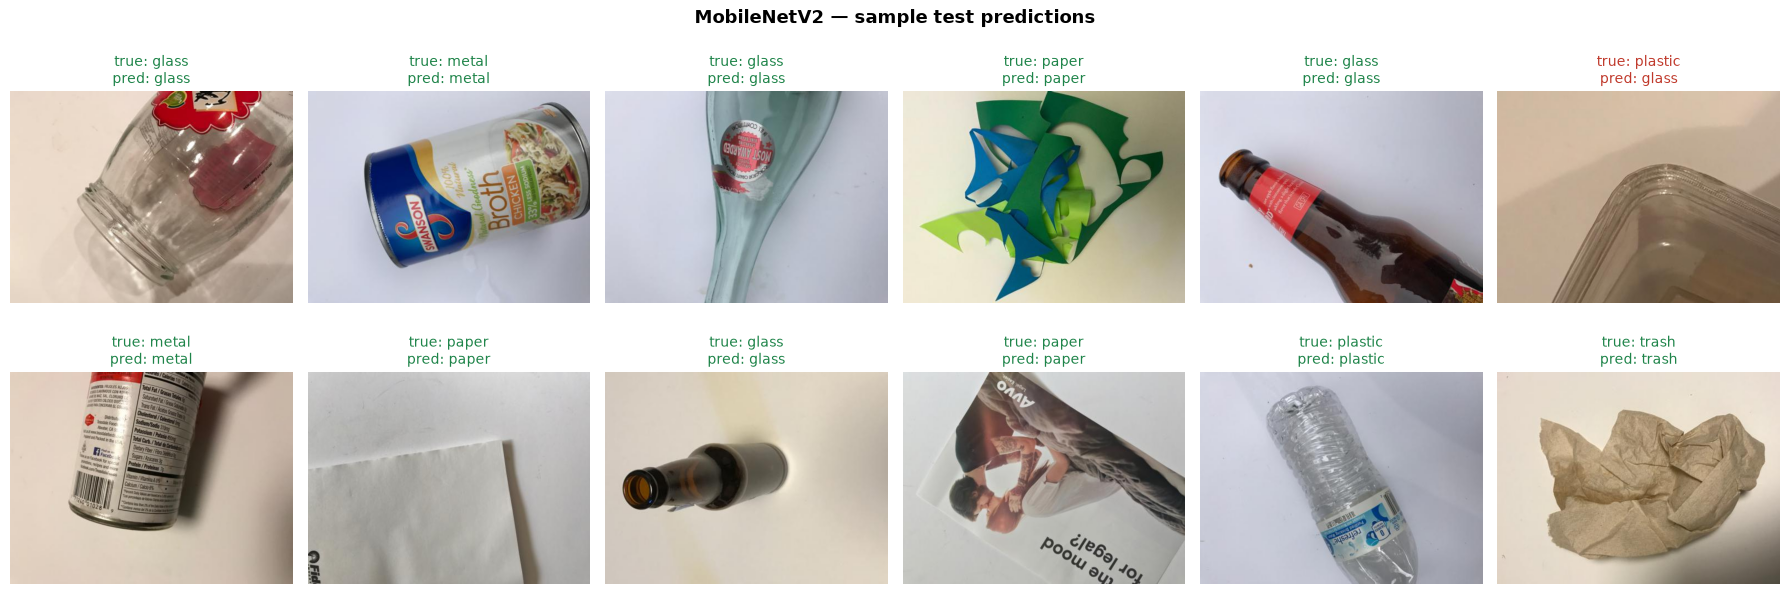

In [17]:
# Model selection uses the VALIDATION set, never the test set
selected_name  = 'MobileNetV2' if mnv2_val_acc >= cnn_val_acc else 'Custom CNN'
selected_model = mnv2_model if selected_name == 'MobileNetV2' else cnn_model
selected_pred  = mnv2_pred if selected_name == 'MobileNetV2' else cnn_pred
print(f'Selected model (by validation accuracy): {selected_name}')

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for ax, i in zip(axes.ravel(), rng.choice(len(test_p), 12, replace=False)):
    ax.imshow(mpimg.imread(test_p[i]))
    ok = selected_pred[i] == test_y[i]
    ax.set_title(f'true: {class_names[test_y[i]]}\npred: {class_names[selected_pred[i]]}',
                 color='#1e8449' if ok else '#c0392b', fontsize=10)
    ax.axis('off')
plt.suptitle(f'{selected_name} — sample test predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Save the Model and Results

The selected model is saved in the native Keras format (`.keras`), which replaces the legacy `.h5` format. `training_history.json` holds the metrics and curves the Streamlit app displays.

In [18]:
# Wrap the trained layers in a fresh, never-compiled model: the app only needs
# inference, so the file doesn't need to carry optimizer state
export_model = keras.Model(selected_model.inputs, selected_model.outputs, name=selected_model.name)
export_model.save('garbage_classifier.keras')
print(f'Saved: garbage_classifier.keras  ({os.path.getsize("garbage_classifier.keras")/1e6:.1f} MB)')

def model_summary(model, hist, val_acc, test_acc, report, **extra):
    return {
        'parameters':         int(model.count_params()),
        'val_accuracy':       float(val_acc),
        'test_accuracy':      float(test_acc),
        'test_macro_f1':      float(report['macro avg']['f1-score']),
        'test_per_class_f1':  {c: float(report[c]['f1-score']) for c in class_names},
        'history':            {k: [float(v) for v in hist[k]] for k in hist},
        **extra,
    }

results = {
    'selected_model': selected_name,
    'class_names':    class_names,
    'split':          {'train': len(train_p), 'val': len(val_p), 'test': len(test_p)},
    'models': {
        'Custom CNN':  model_summary(cnn_model, hist_cnn, cnn_val_acc, cnn_test_acc, cnn_report),
        'MobileNetV2': model_summary(mnv2_model, history_mnv2, mnv2_val_acc, mnv2_test_acc, mnv2_report,
                                     fine_tune_start_epoch=fine_tune_start + 1),
    },
}
with open('training_history.json', 'w') as f:
    json.dump(results, f, indent=1)
print('Saved: training_history.json')

# On Colab, download the artifacts
if os.environ.get('GARBAGE_DATA_DIR') is None:
    !zip -r model_artifacts.zip garbage_classifier.keras class_names.json training_history.json results/
    from google.colab import files
    files.download('model_artifacts.zip')

Saved: garbage_classifier.keras  (9.7 MB)
Saved: training_history.json
